In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
alpha = 2
beta = 1

def f(x):
    return np.sin(128*np.pi*x)

# solucion exacta (la calcule a mano integrando u''=f dos veces
# y usando las condiciones de borde)
def u_exacta(x):
    k = 128*np.pi
    C1 = 1 + np.cos(k)/k   # de la condicion u'(1)=1
    C2 = alpha             # de la condicion u(0)=2
    return -np.sin(k*x)/k**2 + C1*x + C2


def armar_sistema(n):
    M = 2**n + 1          # cantidad de incognitas U_1,...,U_M
    h = 1/(2**n + 1)
    x = np.array([j*h for j in range(M+1)])  # x_0,...,x_M

    A = np.zeros((M, M))
    b = np.zeros(M)

    # ecuaciones interiores, j = 1,...,M-1  -> filas 0,...,M-2
    for j in range(1, M):
        fila = j-1
        b[fila] = f(x[j])
        if j-1 == 0:
            b[fila] -= alpha/h**2   # paso el termino conocido U_0=alpha
        else:
            A[fila, j-2] = 1/h**2
        A[fila, j-1] = -2/h**2
        if j+1 <= M:
            A[fila, j] = 1/h**2

    # ultima fila: condicion de Neumann con backward de orden 2
    # (3/2 U_M - 2 U_{M-1} + 1/2 U_{M-2})/h = beta
    A[M-1, M-1] = 1.5/h
    A[M-1, M-2] = -2/h
    A[M-1, M-3] = 0.5/h
    b[M-1] = beta

    return A, b, x, h

In [3]:
# ---------- item 1: mostrar matrices chicas ----------
print("Para n=3:")
A, b, x, h = armar_sistema(3)
print("A =")
print(np.round(A, 1))
print("b =")
print(np.round(b, 2))

Para n=3:
A =
[[-162.    81.     0.     0.     0.     0.     0.     0.     0. ]
 [  81.  -162.    81.     0.     0.     0.     0.     0.     0. ]
 [   0.    81.  -162.    81.     0.     0.     0.     0.     0. ]
 [   0.     0.    81.  -162.    81.     0.     0.     0.     0. ]
 [   0.     0.     0.    81.  -162.    81.     0.     0.     0. ]
 [   0.     0.     0.     0.    81.  -162.    81.     0.     0. ]
 [   0.     0.     0.     0.     0.    81.  -162.    81.     0. ]
 [   0.     0.     0.     0.     0.     0.    81.  -162.    81. ]
 [   0.     0.     0.     0.     0.     0.     4.5  -18.    13.5]]
b =
[-161.36    0.98    0.87    0.34   -0.34   -0.87   -0.98   -0.64    1.  ]



Orden estimado (pendiente del log-log): 1.7572356952680568

n, h, error:
3 0.1111111111111111 0.18586126118869828
4 0.058823529411764705 0.06403626426383324
5 0.030303030303030304 0.08673157086608407
6 0.015384615384615385 0.16226020584565104
7 0.007751937984496124 0.002345213265933843
8 0.0038910505836575876 0.0014161458903538815
9 0.001949317738791423 0.0005594747245396547
10 0.000975609756097561 0.0001545244472778151
11 0.0004880429477794046 3.9596465554847526e-05
12 0.000244081034903588 9.962385048023492e-06
13 0.00012205541315757354 2.4948951233838557e-06
14 6.1031431187061336e-05 6.242662200506288e-07


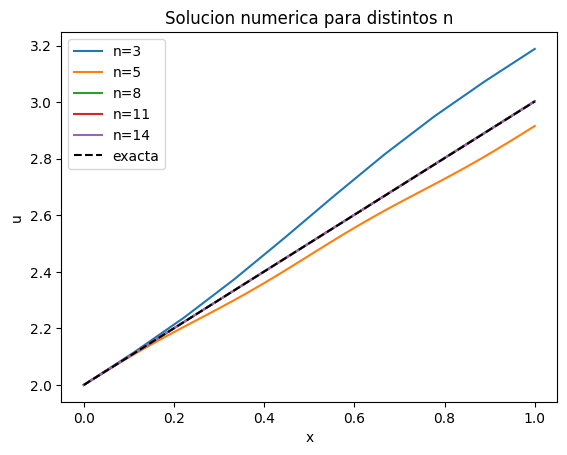

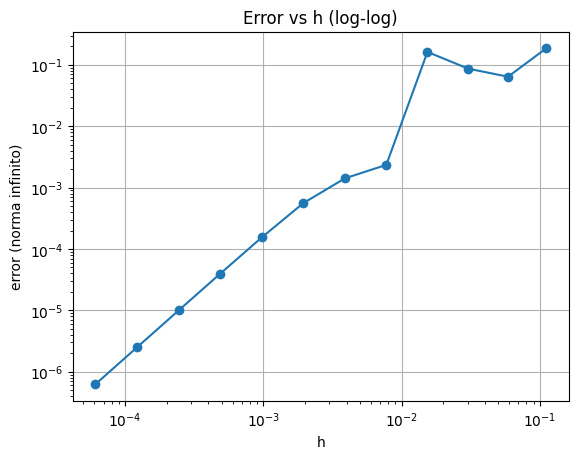

In [5]:
# ---------- item 2: resolver para varios n y ver el error ----------
ns = list(range(3, 15))   # con matriz densa no se puede ir mucho mas lejos (se llena la memoria)
errores = []

plt.figure()
for n in ns:
    A, b, x, h = armar_sistema(n)
    U = np.linalg.solve(A, b)
    U_completo = np.concatenate(([alpha], U))   # le agrego U_0 = alpha

    err = np.max(np.abs(U_completo - u_exacta(x)))
    errores.append(err)

    if n in [3, 5, 8, 11, 14]:   # algunos n representativos
        plt.plot(x, U_completo, label=f"n={n}")

plt.plot(x, u_exacta(x), 'k--', label="exacta")
plt.legend()
plt.xlabel("x")
plt.ylabel("u")
plt.title("Solucion numerica para distintos n")


hs = [1/(2**n+1) for n in ns]

plt.figure()
plt.loglog(hs, errores, 'o-')
plt.xlabel("h")
plt.ylabel("error (norma infinito)")
plt.title("Error vs h (log-log)")
plt.grid(True)


# pendiente del log-log para estimar el orden (ajuste lineal con polyfit)
p = np.polyfit(np.log(hs), np.log(errores), 1)
print("\nOrden estimado (pendiente del log-log):", p[0])

print("\nn, h, error:")
for n, h, e in zip(ns, hs, errores):
    print(n, h, e)